In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv('agriculture_yield_dataset.csv')

df.head()

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,crop_type,soil_type,yield_ton_per_hectare
0,588.6,18.6,242.4,6.5,6.5,Maize,Loamy,5.92
1,772.8,34.6,247.2,10.0,6.5,Maize,Sandy,6.24
2,970.9,36.3,168.4,7.3,6.4,Wheat,Sandy,4.77
3,611.7,19.0,121.7,3.7,6.0,Maize,Loamy,4.04
4,696.1,29.6,184.6,5.1,6.1,Cotton,Clay,5.17


In [3]:
#Q1
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 10 Records:")
display(df.head(10))

Number of Rows: 1500
Number of Columns: 8

Column Names:
['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours', 'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare']

First 10 Records:


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,crop_type,soil_type,yield_ton_per_hectare
0,588.6,18.6,242.4,6.5,6.5,Maize,Loamy,5.92
1,772.8,34.6,247.2,10.0,6.5,Maize,Sandy,6.24
2,970.9,36.3,168.4,7.3,6.4,Wheat,Sandy,4.77
3,611.7,19.0,121.7,3.7,6.0,Maize,Loamy,4.04
4,696.1,29.6,184.6,5.1,6.1,Cotton,Clay,5.17
5,831.9,28.0,190.3,2.1,6.1,Soybean,Loamy,5.50
6,1023.8,32.0,108.5,6.9,6.2,Cotton,Loamy,5.44
7,1142.4,18.4,241.9,4.1,7.3,Soybean,Sandy,5.88
8,810.4,36.4,164.8,9.9,6.5,Wheat,Loamy,6.35
9,1085.5,29.4,89.3,8.3,5.8,Cotton,Loamy,6.30


In [4]:
#Q2
print("Data Types:\n")
print(df.dtypes)

print("\nMissing Values:\n")
print(df.isnull().sum())

missing_cols = df.columns[df.isnull().sum() > 0]

if len(missing_cols) > 0:
    print("\nColumns with Missing Values:")
    print(missing_cols.tolist())
else:
    print("\nNo Missing Values Found")

Data Types:

rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                 object
soil_type                 object
yield_ton_per_hectare    float64
dtype: object

Missing Values:

rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64

No Missing Values Found


In [5]:
#Q3
stats = df.describe()

display(stats)

highest_mean = stats.loc['mean'].idxmax()
highest_std = stats.loc['std'].idxmax()

print("Feature with Highest Mean:", highest_mean)
print("Feature with Highest Standard Deviation:", highest_std)

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,754.054667,27.749467,148.744067,5.403267,6.759133,5.028793
std,255.097216,5.758101,56.990279,2.584329,0.719742,0.968282
min,300.200000,18.000000,50.300000,1.000000,5.500000,2.090000
25%,536.175000,22.600000,98.600000,3.200000,6.100000,4.337500
50%,761.200000,27.700000,146.850000,5.400000,6.800000,5.010000
75%,964.375000,32.600000,196.575000,7.600000,7.400000,5.740000
max,1200.000000,38.000000,249.900000,10.000000,8.000000,7.860000


Feature with Highest Mean: rainfall_mm
Feature with Highest Standard Deviation: rainfall_mm


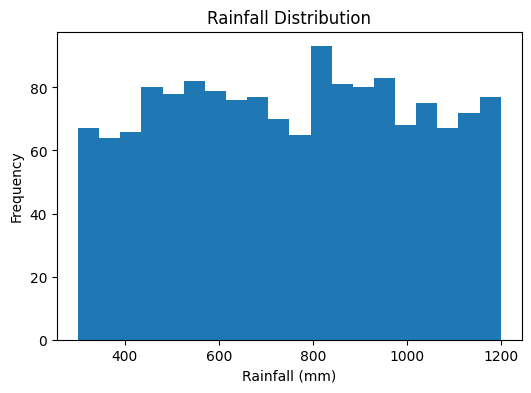

In [6]:
#Q4
plt.figure(figsize=(6,4))
plt.hist(df['rainfall_mm'], bins=20)
plt.title("Rainfall Distribution")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")
plt.show()

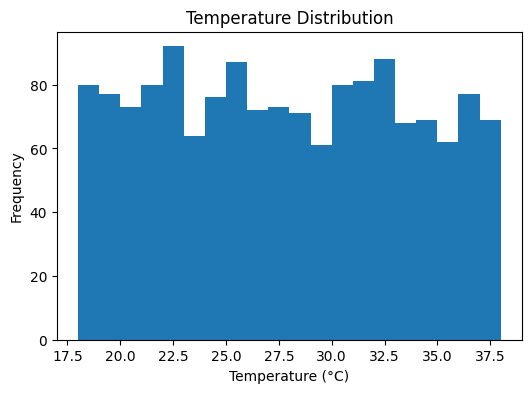

In [7]:
plt.figure(figsize=(6,4))
plt.hist(df['temperature_c'], bins=20)
plt.title("Temperature Distribution")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")
plt.show()

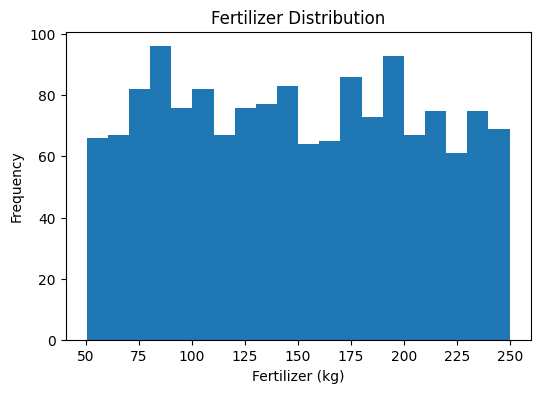

In [8]:
plt.figure(figsize=(6,4))
plt.hist(df['fertilizer_kg'], bins=20)
plt.title("Fertilizer Distribution")
plt.xlabel("Fertilizer (kg)")
plt.ylabel("Frequency")
plt.show()

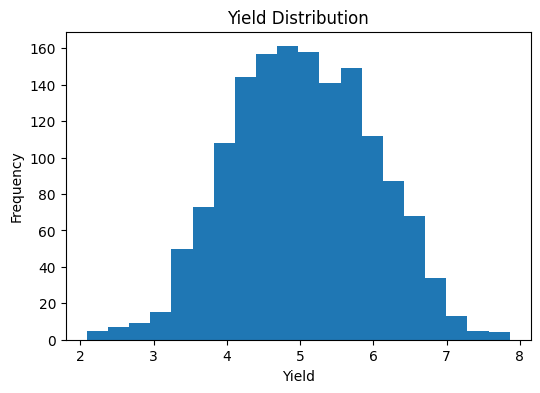

In [9]:
plt.figure(figsize=(6,4))
plt.hist(df['yield_ton_per_hectare'], bins=20)
plt.title("Yield Distribution")
plt.xlabel("Yield")
plt.ylabel("Frequency")
plt.show()

In [10]:
#Q5
crop_counts = df['crop_type'].value_counts()

print(crop_counts)

crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64


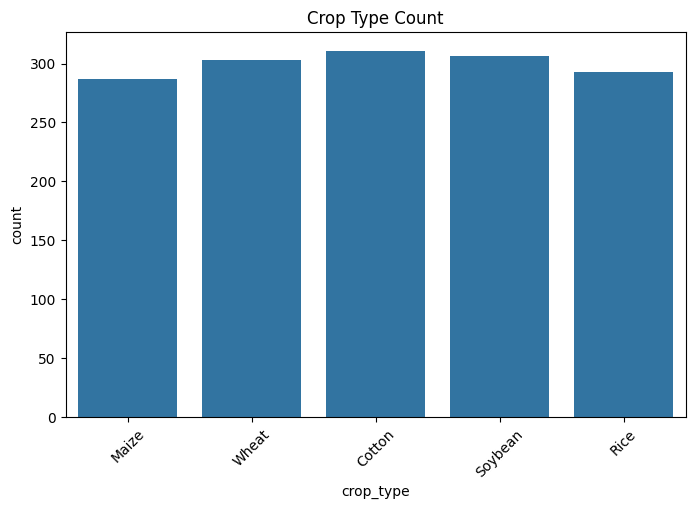

In [11]:
plt.figure(figsize=(8,5))
sns.countplot(x='crop_type', data=df)
plt.title("Crop Type Count")
plt.xticks(rotation=45)
plt.show()

In [12]:
print("Most Frequent Crop:")
print(df['crop_type'].mode()[0])

Most Frequent Crop:
Cotton


In [13]:
#Q6
soil_counts = df['soil_type'].value_counts()

print(soil_counts)

soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64


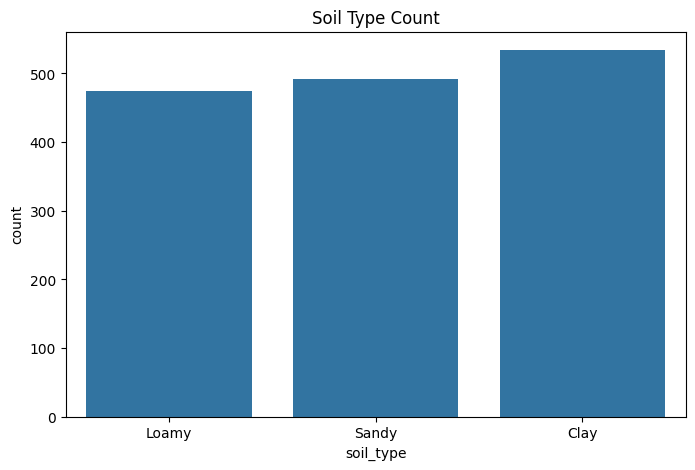

In [14]:
plt.figure(figsize=(8,5))
sns.countplot(x='soil_type', data=df)
plt.title("Soil Type Count")
plt.show()

In [15]:
print("Most Common Soil Type:")
print(df['soil_type'].mode()[0])

Most Common Soil Type:
Clay


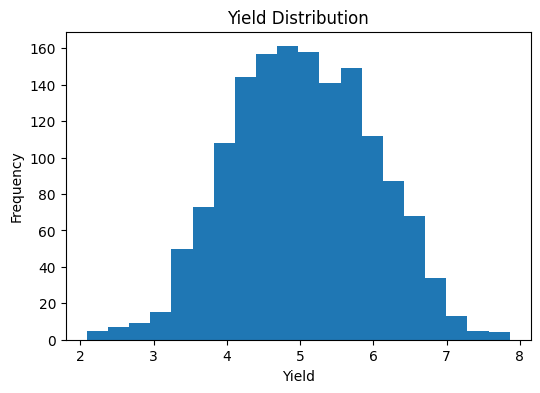

In [16]:
#Q7
plt.figure(figsize=(6,4))
plt.hist(df['yield_ton_per_hectare'], bins=20)
plt.title("Yield Distribution")
plt.xlabel("Yield")
plt.ylabel("Frequency")
plt.show()

In [17]:
print("""
1. Distribution appears approximately normal / not normal.
2. Outliers are present / not present.
""")


1. Distribution appears approximately normal / not normal.
2. Outliers are present / not present.



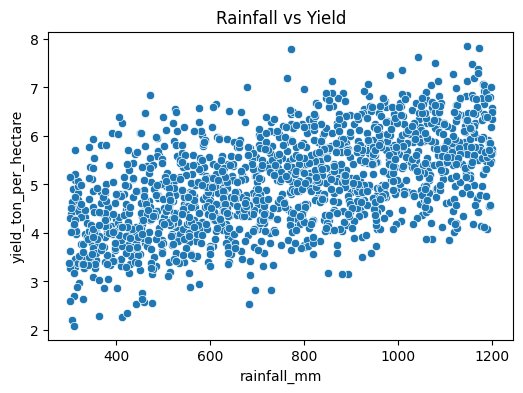

In [18]:
#Q8
plt.figure(figsize=(6,4))
sns.scatterplot(
    x='rainfall_mm',
    y='yield_ton_per_hectare',
    data=df
)
plt.title("Rainfall vs Yield")
plt.show()

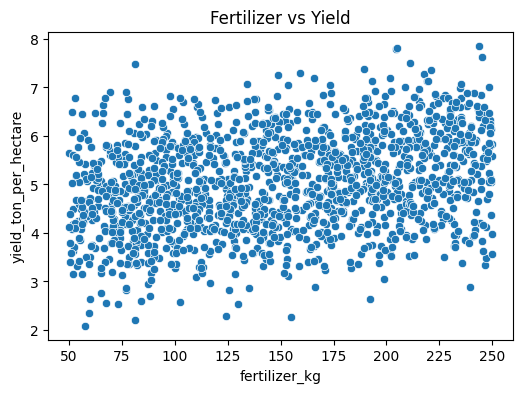

In [19]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    x='fertilizer_kg',
    y='yield_ton_per_hectare',
    data=df
)
plt.title("Fertilizer vs Yield")
plt.show()

In [20]:
print(
    "Rainfall-Yield Correlation:",
    df['rainfall_mm'].corr(df['yield_ton_per_hectare'])
)

print(
    "Fertilizer-Yield Correlation:",
    df['fertilizer_kg'].corr(df['yield_ton_per_hectare'])
)

Rainfall-Yield Correlation: 0.5537042408932247
Fertilizer-Yield Correlation: 0.27804258886930494


In [21]:
#Q9
numeric_df = df.select_dtypes(include=np.number)

corr_matrix = numeric_df.corr()

display(corr_matrix)

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare
rainfall_mm,1.000000,0.026721,0.002558,0.010877,0.006916,0.553704
temperature_c,0.026721,1.000000,0.037468,0.007114,0.001513,-0.022559
fertilizer_kg,0.002558,0.037468,1.000000,-0.010497,0.010001,0.278043
irrigation_hours,0.010877,0.007114,-0.010497,1.000000,0.009307,0.542664
soil_ph,0.006916,0.001513,0.010001,0.009307,1.000000,0.024412
yield_ton_per_hectare,0.553704,-0.022559,0.278043,0.542664,0.024412,1.000000


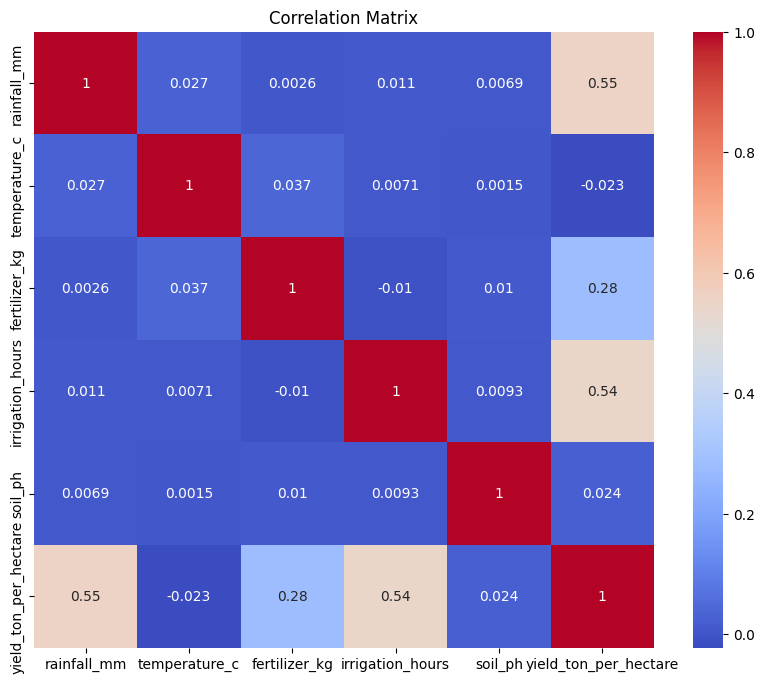

In [22]:
plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Matrix")
plt.show()

In [23]:
yield_corr = corr_matrix['yield_ton_per_hectare']

top_features = (
    yield_corr.drop('yield_ton_per_hectare')
              .abs()
              .sort_values(ascending=False)
)

print(top_features.head(3))

rainfall_mm         0.553704
irrigation_hours    0.542664
fertilizer_kg       0.278043
Name: yield_ton_per_hectare, dtype: float64


In [24]:
#Q10
crop_yield = df.groupby(
    'crop_type'
)['yield_ton_per_hectare'].mean()

print(crop_yield)

crop_type
Cotton     4.607299
Maize      4.897143
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Name: yield_ton_per_hectare, dtype: float64


In [25]:
soil_yield = df.groupby(
    'soil_type'
)['yield_ton_per_hectare'].mean()

print(soil_yield)

soil_type
Clay     5.134326
Loamy    5.366519
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64


In [26]:
print(
    "Highest Yield Crop:",
    crop_yield.idxmax()
)

print(
    "Highest Yield Soil:",
    soil_yield.idxmax()
)

Highest Yield Crop: Rice
Highest Yield Soil: Loamy


In [27]:
#Q11
categorical_cols = df.select_dtypes(
    include='object'
).columns

print(categorical_cols)

Index(['crop_type', 'soil_type'], dtype='object')


In [28]:
df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

display(df_encoded.head())

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare,crop_type_Maize,crop_type_Rice,crop_type_Soybean,crop_type_Wheat,soil_type_Loamy,soil_type_Sandy
0,588.6,18.6,242.4,6.5,6.5,5.92,True,False,False,False,True,False
1,772.8,34.6,247.2,10.0,6.5,6.24,True,False,False,False,False,True
2,970.9,36.3,168.4,7.3,6.4,4.77,False,False,False,True,False,True
3,611.7,19.0,121.7,3.7,6.0,4.04,True,False,False,False,True,False
4,696.1,29.6,184.6,5.1,6.1,5.17,False,False,False,False,False,False


In [29]:
#Q12
X = df_encoded.drop(
    'yield_ton_per_hectare',
    axis=1
)

y = df_encoded[
    'yield_ton_per_hectare'
]

print("Target Variable:")
print(y.name)

Target Variable:
yield_ton_per_hectare


In [31]:
#Q13
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (1200, 11)
X_test : (300, 11)
y_train: (1200,)
y_test : (300,)


In [32]:
#Q14
model = LinearRegression()

model.fit(X_train, y_train)

print("Intercept:")
print(model.intercept_)

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

display(coef_df)


highest_feature = coef_df.sort_values(
    by='Coefficient',
    ascending=False
).iloc[0]

print("Highest Positive Coefficient Feature:")
print(highest_feature)

print(
    "R² Score:",
    model.score(X_test, y_test)
)

Intercept:
1.587132027736121


,Feature,Coefficient
0,rainfall_mm,0.002035
1,temperature_c,-0.009175
2,fertilizer_kg,0.004978
3,irrigation_hours,0.198327
4,soil_ph,0.004901
5,crop_type_Maize,0.238931
6,crop_type_Rice,0.863993
7,crop_type_Soybean,0.481719
8,crop_type_Wheat,0.348474
9,soil_type_Loamy,0.302974


Highest Positive Coefficient Feature:
Feature        crop_type_Rice
Coefficient          0.863993
Name: 6, dtype: object
R² Score: 0.8627866712142435
